In [1]:
import pickle
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad


In [2]:
with open('./DATA/gt_FCs.pkl', 'rb') as file:
    gt_FCs = pickle.load(file)

In [3]:
gt_FCs

,ABCF1,ABL1,ACACA,ACBD5,ACKR2,ACKR3,ACLY,ADAM15,ADAM32,ADPRS,...,XCL1,XKR9,XPO1,XRCC5,ZDHHC16,ZNF593,ZNF622,ZNF658,ZNHIT6,ZYX
ABCF1,-inf,-0.002826,-0.057126,0.020614,0.000000,0.000000,-0.058078,-0.033531,0.000000,-0.018290,...,0.000000,0.026503,-4.519268,4.793215,0.020456,5.000000,3.906943,5.000000,3.856463,0.000000
ABL1,-0.006604,-inf,0.013789,3.322018,-0.015648,-0.040632,0.014019,5.000000,-0.057465,0.729817,...,-0.053146,-5.000000,0.005076,-0.005384,-5.000000,-0.006612,-0.004389,-0.006225,-0.004332,-0.067702
ACACA,-0.069088,0.012884,-inf,0.025850,0.000000,0.000000,1.899783,-0.049596,0.000000,0.000000,...,0.000000,0.040395,0.053110,-0.056329,0.031178,-0.069175,-0.045914,-0.065131,-0.045320,0.000000
ACBD5,0.048409,5.000000,0.038561,-inf,-0.006236,0.000000,0.039204,0.279265,0.000000,0.054415,...,-0.021180,-0.222719,-0.037213,0.039469,-0.171902,0.048469,0.032171,0.045636,0.031755,0.000000
ACKR2,0.000000,-0.010609,0.000000,-0.003357,-inf,-0.004700,0.000000,-0.007275,-0.006648,0.000000,...,0.785043,0.005751,0.000000,0.000000,0.004438,0.000000,0.000000,0.000000,0.000000,-0.007832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF593,5.000000,-0.004894,-0.098911,0.035691,0.000000,0.000000,-0.100559,-0.058056,0.000000,-0.031669,...,0.000000,0.045888,-5.000000,5.000000,0.035418,-inf,5.000000,5.000000,5.000000,0.000000
ZNF622,5.000000,-0.002615,-0.052864,0.019076,0.000000,0.000000,-0.053745,-0.031029,0.000000,-0.016926,...,0.000000,0.024526,-4.190454,4.444469,0.018930,5.000000,-inf,5.000000,3.575873,0.000000
ZNF658,3.282901,-0.001574,-0.031822,0.011483,0.000000,0.000000,-0.032352,-0.018678,0.000000,-0.010188,...,0.000000,0.014763,-2.523630,2.676606,0.011395,3.287002,2.181697,-inf,2.153509,0.000000
ZNHIT6,5.000000,-0.008519,-0.172180,0.062130,0.000000,0.000000,-0.175048,-0.101062,0.000000,-0.055127,...,0.000000,0.079880,-5.000000,5.000000,0.061654,5.000000,5.000000,5.000000,-inf,0.000000


In [4]:
adata = sc.read_h5ad('./DATA/perturbseq_all_KOs.h5ad')

adata.X.dtype

dtype('float64')

In [5]:
# Estimated log2 FC using mean(log2(X+1))-difference, matching the
# simulator's log1p-shift ground truth exactly in expectation.
raw = adata.layers['raw_counts']
import scipy.sparse as sp
if sp.issparse(raw):
    raw = raw.toarray()
raw = np.asarray(raw, dtype=np.float64)

groups = adata.obs['perturbation'].values
ctrl_mask = groups == 'control'

# Pre-compute control log2-mean once
log2_ctrl_mean = np.log2(raw[ctrl_mask] + 1).mean(axis=0)

perts = [p for p in np.unique(groups) if p != 'control']
log2fc_rows = {}
for p in perts:
    log2_pert_mean = np.log2(raw[groups == p] + 1).mean(axis=0)
    log2fc_rows[p] = log2_pert_mean - log2_ctrl_mean

est_FCs = pd.DataFrame(log2fc_rows, index=adata.var_names).T
print(f"Estimated log2 FC matrix: {est_FCs.shape}")
est_FCs.head()

Estimated log2 FC matrix: (100, 5000)


,ABCF1,ABL1,ACACA,ACBD5,ACKR2,ACKR3,ACLY,ADAM15,ADAM32,ADPRS,...,XCL1,XKR9,XPO1,XRCC5,ZDHHC16,ZNF593,ZNF622,ZNF658,ZNHIT6,ZYX
ABCF1,-0.725434,-0.005561,-0.027174,0.089478,-0.072974,-0.013657,0.056745,-0.060723,0.071501,0.030881,...,-0.005663,-0.013472,-4.549049,4.817691,-0.027741,5.024729,3.972171,4.926771,3.871113,0.007068
ABL1,0.029415,-0.045585,0.004213,3.341934,0.028286,-0.069940,-0.069564,4.953733,-0.057047,0.782276,...,-0.013483,-4.956323,0.052434,0.014868,-5.048206,-0.014801,0.044743,-0.025918,-0.005989,-0.074522
ACACA,-0.154803,-0.012107,-1.363331,0.054672,-0.004694,0.034535,1.947119,-0.006835,-0.077991,-0.011999,...,0.002136,0.116587,-0.027707,-0.047831,0.014226,-0.002650,-0.008356,-0.070316,-0.017822,0.033938
ACBD5,0.011476,4.984240,-0.080459,-1.469346,-0.021430,0.041171,0.031943,0.269719,-0.052816,0.059146,...,-0.032876,-0.239419,0.015770,-0.029275,-0.172576,0.099003,-0.009563,0.007468,0.004504,-0.003209
ACKR2,-0.009581,-0.023860,0.058211,-0.042361,-0.006000,-0.014551,-0.079789,-0.003697,0.004921,0.021981,...,0.840744,-0.029288,-0.014497,-0.003690,0.003979,-0.096784,0.004208,-0.049552,0.027296,0.010668


In [6]:
# Align rows and columns
common_perts = gt_FCs.index.intersection(est_FCs.index)
common_genes = gt_FCs.columns.intersection(est_FCs.columns)
gt = gt_FCs.loc[common_perts, common_genes].copy()
est = est_FCs.loc[common_perts, common_genes].copy()

# Mask self-perturbations (-inf in ground truth)
mask = np.isfinite(gt.values)
print(f"Shared perturbations: {len(common_perts)}, Shared genes: {len(common_genes)}")
print(f"Valid entries (excl. self-perturbation): {mask.sum():,} / {mask.size:,}")

# Categorize genes
real_genes = [g for g in common_genes if not g.startswith('SYN_') and not g.startswith('GENE_')]
syn_genes = [g for g in common_genes if g.startswith('SYN_')]
filler_genes = [g for g in common_genes if g.startswith('GENE_')]
gene_categories = {'Real': real_genes, 'Synthetic': syn_genes, 'Filler': filler_genes}
print(f"Gene categories — Real: {len(real_genes)}, Synthetic: {len(syn_genes)}, Filler: {len(filler_genes)}")

Shared perturbations: 100, Shared genes: 5000
Valid entries (excl. self-perturbation): 499,900 / 500,000
Gene categories — Real: 678, Synthetic: 182, Filler: 4140


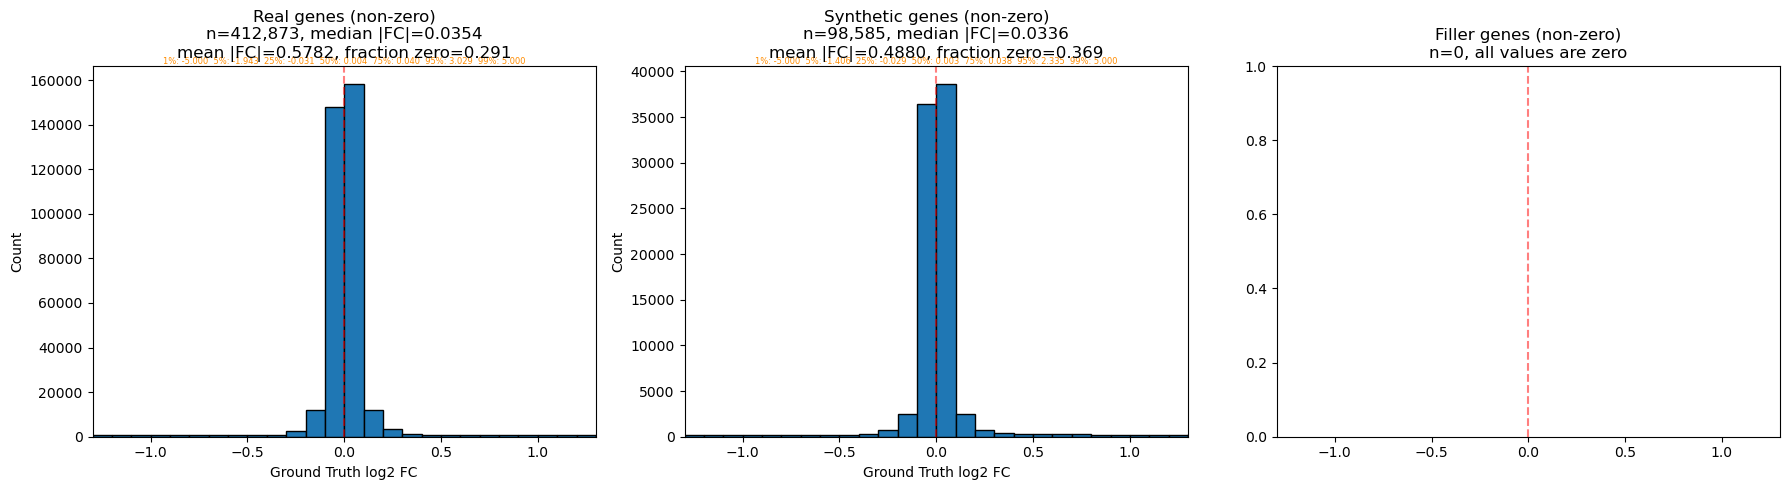

Quantiles of non-zero GT log2 FC (and |FC|):
  Quantile        Real   Synthetic      Filler  |      |Real|  |Synthetic|    |Filler|
        1%     -5.0000     -5.0000         nan  |      0.0011      0.0011         nan
        5%     -1.9434     -1.4059         nan  |      0.0038      0.0034         nan
       25%     -0.0314     -0.0294         nan  |      0.0161      0.0156         nan
       50%      0.0042      0.0034         nan  |      0.0354      0.0336         nan
       75%      0.0396      0.0380         nan  |      0.1077      0.0904         nan
       95%      3.0294      2.3354         nan  |      4.7876      3.8011         nan
       99%      5.0000      5.0000         nan  |      5.0000      5.0000         nan


In [7]:
# Distribution of ground truth log2 fold changes by gene category
import matplotlib.pyplot as plt

real_genes = [g for g in gt_FCs.columns if not g.startswith('SYN_') and not g.startswith('GENE_')]
syn_genes = [g for g in gt_FCs.columns if g.startswith('SYN_')]
filler_genes = [g for g in gt_FCs.columns if g.startswith('GENE_')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

quantiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

for ax, (label, genes) in zip(axes, [('Real', real_genes), ('Synthetic', syn_genes), ('Filler', filler_genes)]):
    vals = gt_FCs[genes].values
    vals = vals[np.isfinite(vals)]
    nonzero = vals[vals != 0]
    if len(nonzero) == 0:
        ax.set_title(f'{label} genes (non-zero)\nn=0, all values are zero')
        ax.axvline(0, color='red', linestyle='--', alpha=0.5)
        ax.set_xlim(-1.3, 1.3)
        continue
    ax.hist(nonzero, bins=100, edgecolor='black')
    ax.set_xlabel('Ground Truth log2 FC')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} genes (non-zero)\nn={len(nonzero):,}, '
                 f'median |FC|={np.median(np.abs(nonzero)):.4f}\n'
                 f'mean |FC|={np.mean(np.abs(nonzero)):.4f}, '
                 f'fraction zero={1 - len(nonzero)/vals.size:.3f}')
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlim(-1.3, 1.3)

    q_vals = np.quantile(nonzero, quantiles)
    q_text = "  ".join([f"{q:.0%}: {v:.3f}" for q, v in zip(quantiles, q_vals)])
    ax.text(0.5, 1.0, q_text, transform=ax.transAxes, fontsize=6,
            ha='center', va='bottom', color='darkorange')

plt.tight_layout()
plt.show()

# Print quantile table
print("Quantiles of non-zero GT log2 FC (and |FC|):")
print(f"{'Quantile':>10s}  {'Real':>10s}  {'Synthetic':>10s}  {'Filler':>10s}  |  {'|Real|':>10s}  {'|Synthetic|':>10s}  {'|Filler|':>10s}")
for q in quantiles:
    vals_by_cat = []
    abs_vals_by_cat = []
    for genes in [real_genes, syn_genes, filler_genes]:
        v = gt_FCs[genes].values
        v = v[np.isfinite(v)]
        v = v[v != 0]
        if len(v) == 0:
            vals_by_cat.append(np.nan)
            abs_vals_by_cat.append(np.nan)
        else:
            vals_by_cat.append(np.quantile(v, q))
            abs_vals_by_cat.append(np.quantile(np.abs(v), q))
    print(f"{q:>10.0%}  {vals_by_cat[0]:>10.4f}  {vals_by_cat[1]:>10.4f}  {vals_by_cat[2]:>10.4f}  "
          f"|  {abs_vals_by_cat[0]:>10.4f}  {abs_vals_by_cat[1]:>10.4f}  {abs_vals_by_cat[2]:>10.4f}")

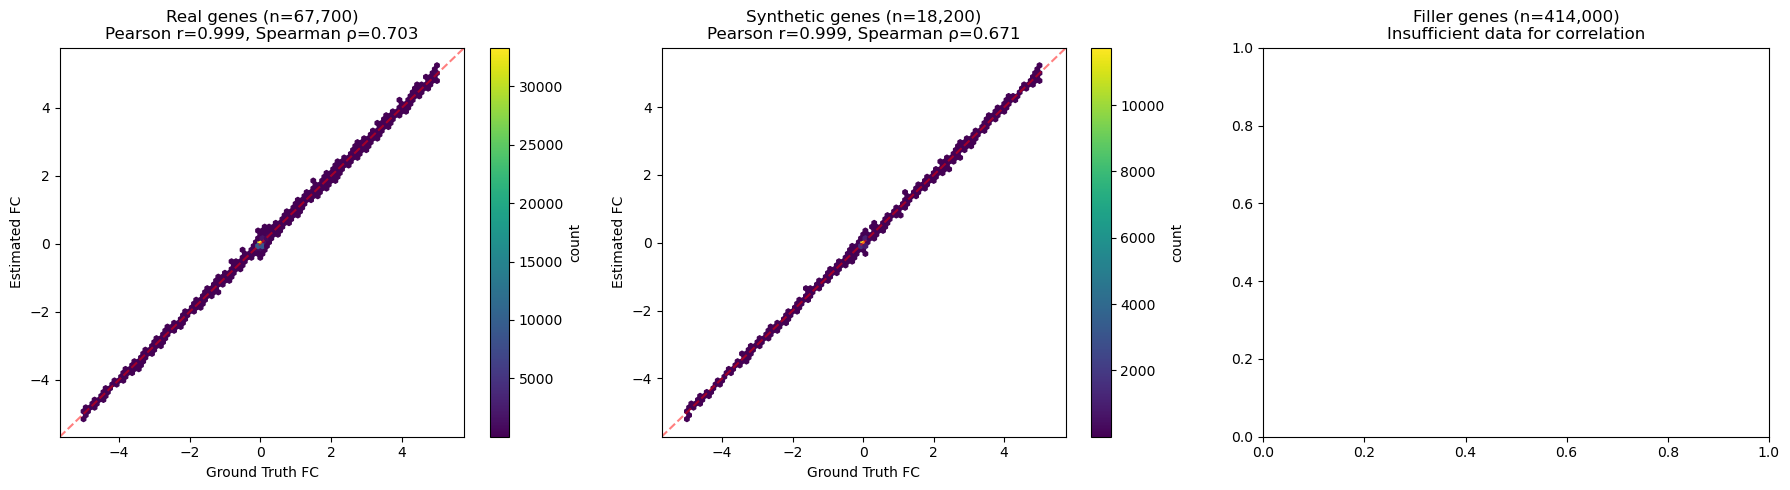

In [8]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, (cat_label, cat_genes) in enumerate(gene_categories.items()):
    gt_cat = gt[cat_genes]
    est_cat = est[cat_genes]
    mask_cat = np.isfinite(gt_cat.values)
    gt_flat = gt_cat.values[mask_cat]
    est_flat = est_cat.values[mask_cat]

    ax = axes[col]
    g, e = gt_flat, est_flat
    if len(g) < 2 or np.std(g) == 0 or np.std(e) == 0:
        ax.set_title(f'{cat_label} genes (n={len(g):,})\nInsufficient data for correlation')
        continue
    r_p, _ = pearsonr(g, e)
    r_s, _ = spearmanr(g, e)
    ax.hexbin(g, e, gridsize=80, cmap='viridis', mincnt=1)
    ax.set_xlabel('Ground Truth FC')
    ax.set_ylabel('Estimated FC')
    ax.set_title(f'{cat_label} genes (n={len(g):,})\nPearson r={r_p:.3f}, Spearman ρ={r_s:.3f}')
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'r--', alpha=0.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    plt.colorbar(ax.collections[0], ax=ax, label='count')

plt.tight_layout()
plt.show()

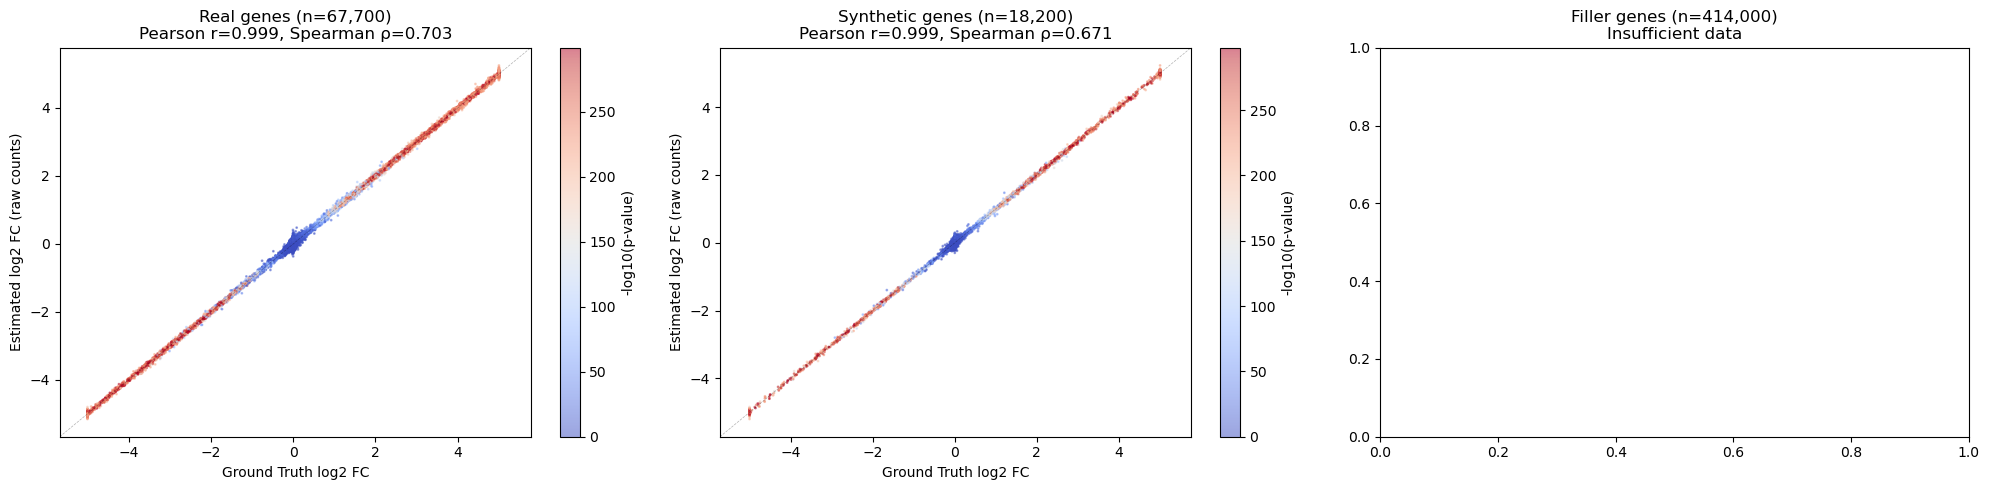

In [9]:
# Ground truth vs est_FCs (from raw counts), colored by DE p-values
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

degs = pd.read_csv('SimulatedData_degs_sf.csv', index_col=0)
degs['neg_log10_pval'] = -np.log10(degs['p_value'].clip(lower=1e-300))

# Pivot p-values to (perturbation x gene) matrix
pval_matrix = degs.pivot(index='target', columns='feature', values='neg_log10_pval')

# Align gt, est, and pval on common indices
common_perts_de = gt.index.intersection(est.index).intersection(pval_matrix.index)
common_genes_de = gt.columns.intersection(est.columns).intersection(pval_matrix.columns)
gt_a = gt.loc[common_perts_de, common_genes_de]
est_a = est.loc[common_perts_de, common_genes_de]
pval_a = pval_matrix.loc[common_perts_de, common_genes_de]

# Categorize genes
real_genes_de = [g for g in common_genes_de if not g.startswith('SYN_') and not g.startswith('GENE_')]
syn_genes_de = [g for g in common_genes_de if g.startswith('SYN_')]
filler_genes_de = [g for g in common_genes_de if g.startswith('GENE_')]
gene_categories_de = {'Real': real_genes_de, 'Synthetic': syn_genes_de, 'Filler': filler_genes_de}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for col, (cat_label, cat_genes) in enumerate(gene_categories_de.items()):
    ax = axes[col]
    gt_cat = gt_a[cat_genes].values
    est_cat = est_a[cat_genes].values
    pval_cat = pval_a[cat_genes].values

    mask = np.isfinite(gt_cat) & np.isfinite(est_cat) & np.isfinite(pval_cat)
    g = gt_cat[mask]
    e = est_cat[mask]
    p = pval_cat[mask]

    if len(g) < 2 or np.std(g) == 0 or np.std(e) == 0:
        ax.set_title(f'{cat_label} genes (n={len(g):,})\nInsufficient data')
        continue

    r_p, _ = pearsonr(g, e)
    r_s, _ = spearmanr(g, e)

    p_capped = np.clip(p, 0, np.percentile(p, 99))

    sc = ax.scatter(g, e, c=p_capped, cmap='coolwarm', s=1, alpha=0.5,
                    norm=Normalize(vmin=0, vmax=p_capped.max()))
    ax.set_xlabel('Ground Truth log2 FC')
    ax.set_ylabel('Estimated log2 FC (raw counts)')
    ax.set_title(f'{cat_label} genes (n={len(g):,})\nPearson r={r_p:.3f}, Spearman ρ={r_s:.3f}')
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=0.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    plt.colorbar(sc, ax=ax, label='-log10(p-value)')

plt.tight_layout()
plt.show()

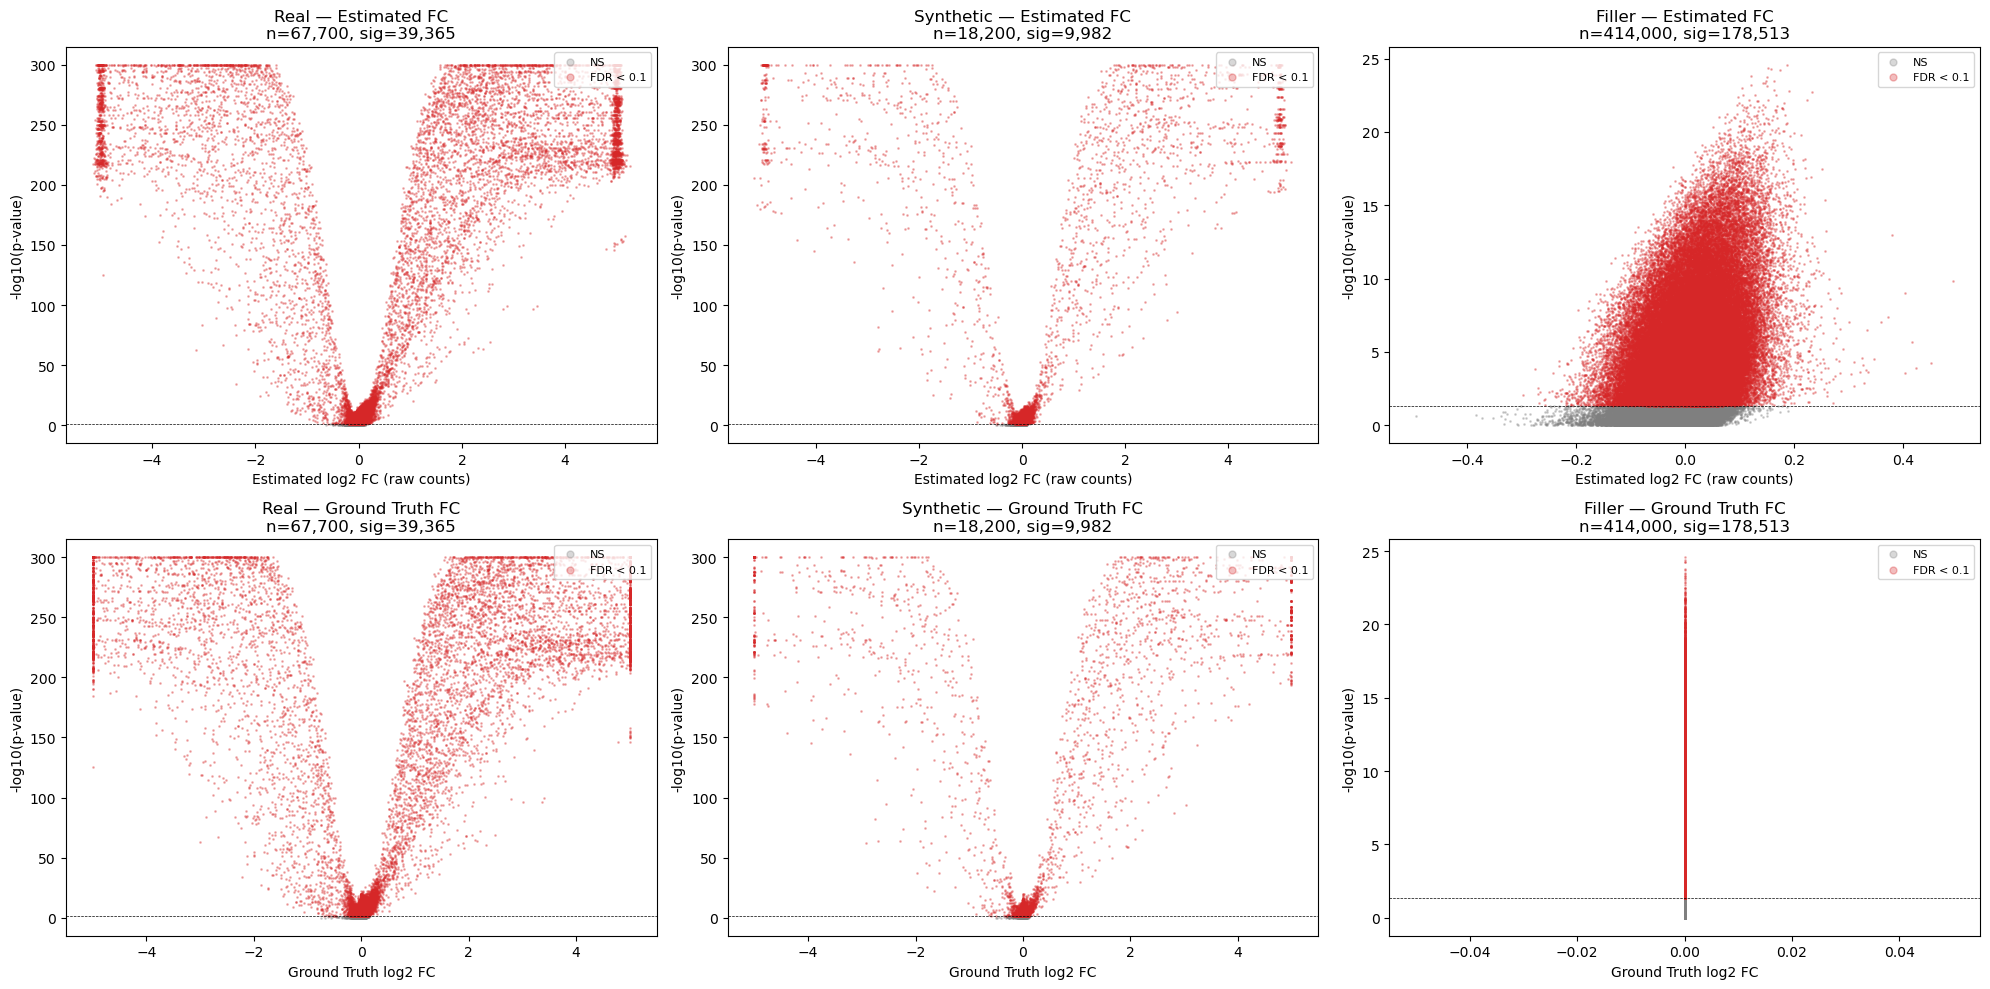

In [10]:
# Volcano plots: estimated FC and ground truth FC vs -log10(p-value)
# Significance: FDR < fdr_thresh
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

fdr_thresh = 0.1
fdr_matrix = degs.pivot(index='target', columns='feature', values='fdr')
fdr_a = fdr_matrix.loc[common_perts_de, common_genes_de]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for col, (cat_label, cat_genes) in enumerate(gene_categories_de.items()):
    gt_cat = gt_a[cat_genes].values
    est_cat = est_a[cat_genes].values
    pval_cat = pval_a[cat_genes].values
    fdr_cat = fdr_a[cat_genes].values

    mask = (np.isfinite(gt_cat) & np.isfinite(est_cat)
            & np.isfinite(pval_cat) & np.isfinite(fdr_cat))
    g = gt_cat[mask]
    e = est_cat[mask]
    p = pval_cat[mask]
    q = fdr_cat[mask]

    if len(g) < 2:
        axes[0, col].set_title(f'{cat_label} — Insufficient data')
        axes[1, col].set_title(f'{cat_label} — Insufficient data')
        continue

    sig = q < fdr_thresh
    # FDR threshold line in -log10(p) units: lowest -log10(p) among sig hits
    fdr_line = p[sig].min() if sig.any() else None

    # Top row: Estimated FC volcano
    ax = axes[0, col]
    ax.scatter(e[~sig], p[~sig], s=1, alpha=0.3, c='tab:grey', label='NS')
    ax.scatter(e[sig], p[sig], s=1, alpha=0.3, c='tab:red',
               label=f'FDR < {fdr_thresh}')
    if fdr_line is not None:
        ax.axhline(fdr_line, color='black', linestyle='--', linewidth=0.5)
    ax.set_xlabel('Estimated log2 FC (raw counts)')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title(f'{cat_label} — Estimated FC\nn={len(e):,}, sig={sig.sum():,}')
    ax.legend(markerscale=5, loc='upper right', fontsize=8)

    # Bottom row: Ground truth FC volcano
    ax = axes[1, col]
    ax.scatter(g[~sig], p[~sig], s=1, alpha=0.3, c='tab:grey', label='NS')
    ax.scatter(g[sig], p[sig], s=1, alpha=0.3, c='tab:red',
               label=f'FDR < {fdr_thresh}')
    if fdr_line is not None:
        ax.axhline(fdr_line, color='black', linestyle='--', linewidth=0.5)
    ax.set_xlabel('Ground Truth log2 FC')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title(f'{cat_label} — Ground Truth FC\nn={len(g):,}, sig={sig.sum():,}')
    ax.legend(markerscale=5, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

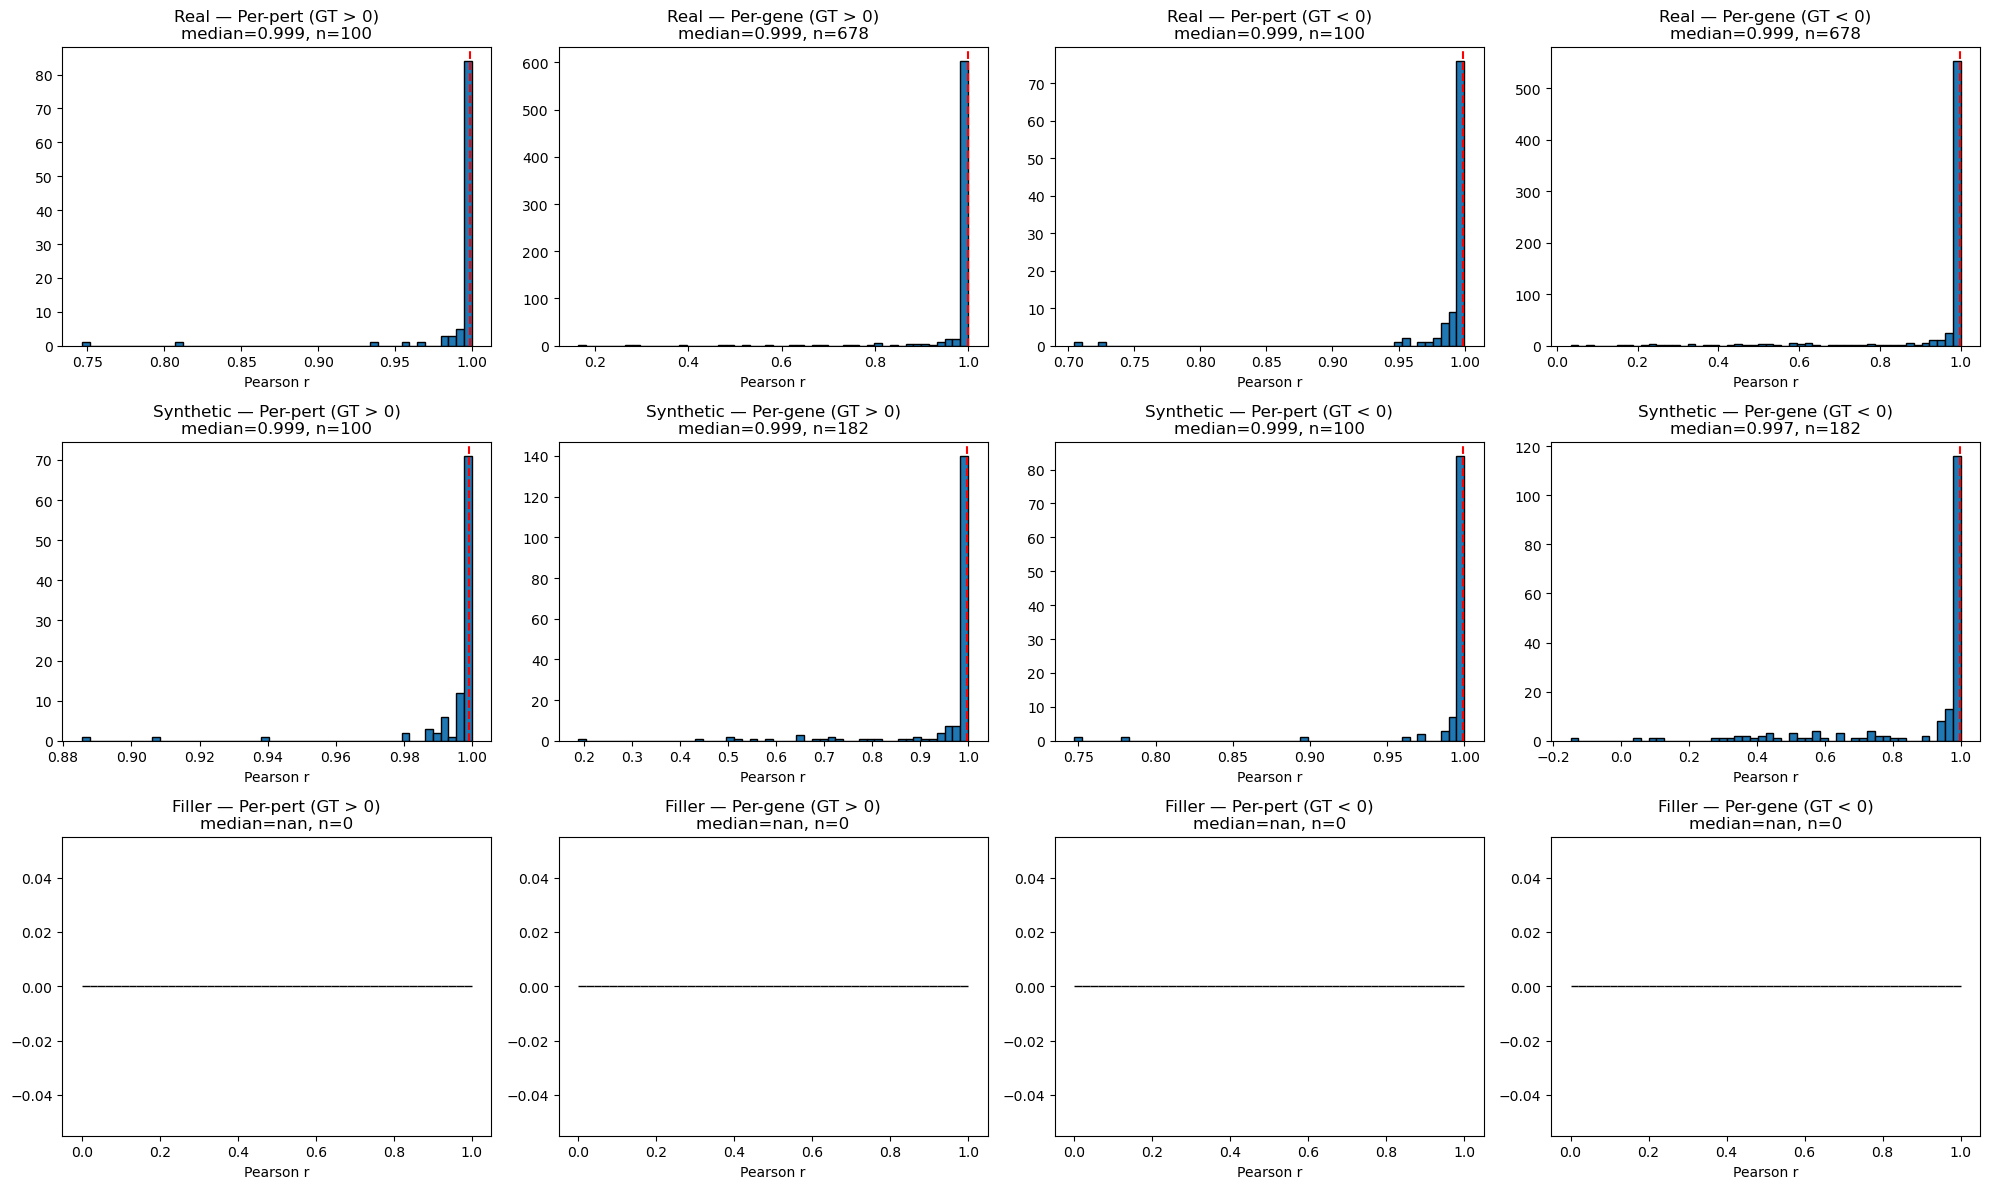

In [11]:
# --- Per-perturbation and per-gene correlations, split by GT sign and gene category ---
def row_col_corrs(gt_df, est_df, sign_cond, items, axis):
    """Pearson r per row (axis=0) or column (axis=1) restricted to sign_cond entries."""
    corrs = []
    for item in items:
        if axis == 0:
            g_row, e_row = gt_df.loc[item], est_df.loc[item]
        else:
            g_row, e_row = gt_df[item], est_df[item]
        m = np.isfinite(g_row.values) & sign_cond(g_row.values)
        if m.sum() >= 3:
            r, _ = pearsonr(g_row.values[m], e_row.values[m])
        else:
            r = np.nan
        corrs.append(r)
    return pd.Series(corrs, index=items)

sign_conds = {'GT > 0': lambda x: x > 0, 'GT < 0': lambda x: x < 0}

fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for row, (cat_label, cat_genes) in enumerate(gene_categories.items()):
    gt_cat = gt[cat_genes]
    est_cat = est[cat_genes]

    col_idx = 0
    for sign_label, sign_fn in sign_conds.items():
        # Per-perturbation
        corrs = row_col_corrs(gt_cat, est_cat, sign_fn, common_perts, axis=0).dropna()
        ax = axes[row, col_idx]
        ax.hist(corrs, bins=50, edgecolor='black')
        ax.axvline(corrs.median(), color='red', linestyle='--')
        ax.set_xlabel('Pearson r')
        ax.set_title(f'{cat_label} — Per-pert ({sign_label})\nmedian={corrs.median():.3f}, n={len(corrs)}')

        # Per-gene
        corrs = row_col_corrs(gt_cat, est_cat, sign_fn, cat_genes, axis=1).dropna()
        ax = axes[row, col_idx + 1]
        ax.hist(corrs, bins=50, edgecolor='black')
        ax.axvline(corrs.median(), color='red', linestyle='--')
        ax.set_xlabel('Pearson r')
        ax.set_title(f'{cat_label} — Per-gene ({sign_label})\nmedian={corrs.median():.3f}, n={len(corrs)}')

        col_idx += 2

plt.tight_layout()
plt.show()

In [12]:
deRes=pd.read_csv("SimulatedData_degs.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'SimulatedData_degs.csv'

In [ ]:
sum(deRes["fold_change"] > 1)

In [ ]:
# --- Precision-Recall for non-zero effect detection, per gene category ---
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (cat_label, cat_genes) in zip(axes, gene_categories.items()):
    gt_cat = gt[cat_genes]
    est_cat = est[cat_genes]
    mask_cat = np.isfinite(gt_cat.values)

    gt_binary = (gt_cat.values[mask_cat] != 0).astype(int)
    est_scores = np.abs(est_cat.values[mask_cat])

    auroc = roc_auc_score(gt_binary, est_scores)
    ap = average_precision_score(gt_binary, est_scores)
    prevalence = gt_binary.mean()

    precision, recall, _ = precision_recall_curve(gt_binary, est_scores)
    ax.plot(recall, precision)
    ax.axhline(prevalence, color='grey', linestyle='--', label=f'baseline={prevalence:.3f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{cat_label} genes\nAUROC={auroc:.3f}, AP={ap:.3f}')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- Top/bottom perturbations and genes by correlation, per category ---
for cat_label, cat_genes in gene_categories.items():
    gt_cat = gt[cat_genes]
    est_cat = est[cat_genes]

    pert_corrs = row_col_corrs(gt_cat, est_cat, lambda x: x != 0, common_perts, axis=0).dropna()
    gene_corrs = row_col_corrs(gt_cat, est_cat, lambda x: x != 0, cat_genes, axis=1).dropna()

    print(f"\n{'='*60}")
    print(f"  {cat_label} genes")
    print(f"{'='*60}")
    print(f"\nTop 5 perturbations:")
    print(pert_corrs.sort_values(ascending=False).head().to_string())
    print(f"\nBottom 5 perturbations:")
    print(pert_corrs.sort_values().head().to_string())
    print(f"\nTop 5 genes:")
    print(gene_corrs.sort_values(ascending=False).head().to_string())
    print(f"\nBottom 5 genes:")
    print(gene_corrs.sort_values().head().to_string())